Epoch    1  train_loss=0.824515  test_loss=1.113697
Epoch  500  train_loss=0.005694  test_loss=0.006572
Epoch 1000  train_loss=0.004353  test_loss=0.004974
Epoch 1500  train_loss=0.003233  test_loss=0.003650
Epoch 2000  train_loss=0.002553  test_loss=0.002889
Epoch 2500  train_loss=0.002197  test_loss=0.002479
Epoch 3000  train_loss=0.001988  test_loss=0.002249
Epoch 3500  train_loss=0.001864  test_loss=0.002109
Epoch 4000  train_loss=0.001786  test_loss=0.002026
Epoch 4500  train_loss=0.001736  test_loss=0.001971
Epoch 5000  train_loss=0.001697  test_loss=0.001930


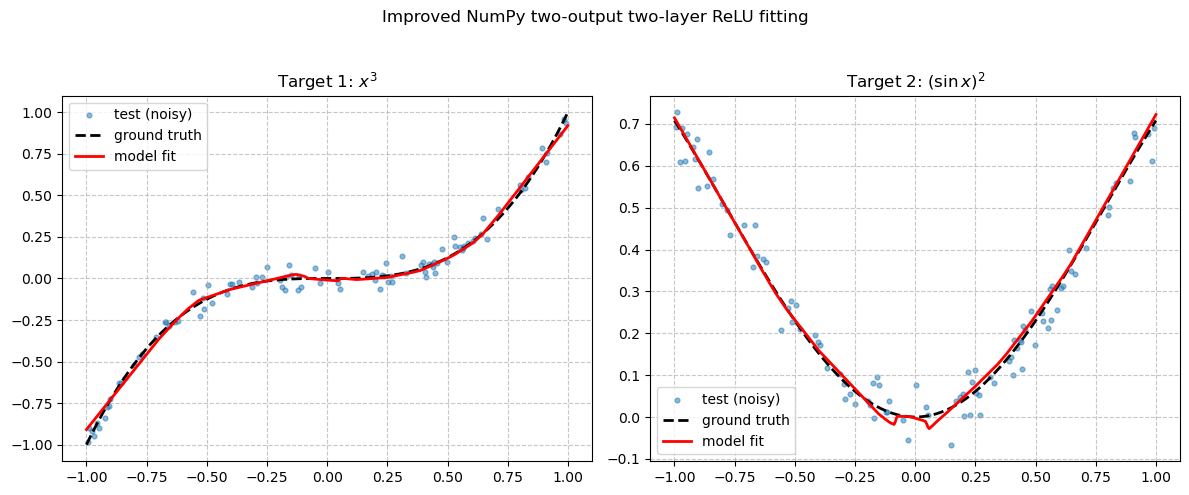

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# 设置随机种子
np.random.seed(42)

def f(x):
    y1 = x**3
    y2 = np.sin(x)**2
    return np.concatenate([y1, y2], axis=1)

# 数据生成，采样并为两个目标添加少量噪声
N = 500
x = np.linspace(-1, 1, N)[:, None]
noise = 0.04 * np.random.randn(N, 2)
y = f(x) + noise

perm = np.random.permutation(N)
train_idx, test_idx = perm[:400], perm[400:]
x_train, y_train = x[train_idx], y[train_idx]
x_test, y_test = x[test_idx], y[test_idx]


# 模型参数
in_dim = 1
hidden = 128 # 增加隐藏层神经元数量
out_dim = 2

# 使用 He 初始化 (Kaiming Initialization)
W1 = np.random.randn(in_dim, hidden) * np.sqrt(2.0 / in_dim)
b1 = np.zeros((1, hidden))
W2 = np.random.randn(hidden, out_dim) * np.sqrt(2.0 / hidden)
b2 = np.zeros((1, out_dim))

# 激活函数及其梯度
def relu(x):
    return np.maximum(0, x)

def relu_grad(x):
    return (x > 0).astype(np.float32)

def forward(x):
    z1 = x.dot(W1) + b1
    a1 = relu(z1)
    y_pred = a1.dot(W2) + b2 
    cache = (x, z1, a1)
    return y_pred, cache

def backward(y_pred, y_true, cache):
    x, z1, a1 = cache
    B = x.shape[0]
    dL_dy = 2.0 * (y_pred - y_true) / B
    dW2 = a1.T.dot(dL_dy)
    db2 = np.sum(dL_dy, axis=0, keepdims=True)
    da1 = dL_dy.dot(W2.T)
    dz1 = da1 * relu_grad(z1)
    dW1 = x.T.dot(dz1)
    db1 = np.sum(dz1, axis=0, keepdims=True)
    return dW1, db1, dW2, db2

# 训练配置
lr = 0.05 # 提高学习率
epochs = 5000 # 增加训练轮数
print_interval = 500

# 记录 Loss 变化
history = {'train': [], 'test': []}

for ep in range(1, epochs+1):
    y_pred, cache = forward(x_train)
    loss = np.mean((y_pred - y_train)**2)
    dW1, db1, dW2, db2 = backward(y_pred, y_train, cache)
    
    # 简单的权重更新
    W1 -= lr * dW1
    b1 -= lr * db1
    W2 -= lr * dW2
    b2 -= lr * db2

    if ep % print_interval == 0 or ep == 1:
        y_test_pred, _ = forward(x_test)
        test_loss = np.mean((y_test_pred - y_test)**2)
        history['train'].append(loss)
        history['test'].append(test_loss)
        print(f"Epoch {ep:4d}  train_loss={loss:.6f}  test_loss={test_loss:.6f}")

# 可视化结果
xs = np.linspace(-1, 1, 400)[:, None]
y_true = f(xs)
y_fit, _ = forward(xs)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(x_test, y_test[:, 0:1], s=12, label='test (noisy)', alpha=0.5)
plt.plot(xs, y_true[:, 0:1], 'k--', label='ground truth', linewidth=2)
plt.plot(xs, y_fit[:, 0:1], 'r', label='model fit', linewidth=2)
plt.title(r'Target 1: $x^3$')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.subplot(1, 2, 2)
plt.scatter(x_test, y_test[:, 1:2], s=12, label='test (noisy)', alpha=0.5)
plt.plot(xs, y_true[:, 1:2], 'k--', label='ground truth', linewidth=2)
plt.plot(xs, y_fit[:, 1:2], 'r', label='model fit', linewidth=2)
plt.title(r'Target 2: $(\sin x)^2$')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.suptitle('Improved NumPy two-output two-layer ReLU fitting')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

报告：

NumPy手写神经网络多目标函数拟合

一、函数定义
本实验模拟了两个非线性函数：
1. $y_1 = x^3$
2. $y_2 = (sin x)^2
这两个函数具有不同的非线性特征，用于测试模型的通用近似能力。

二、数据采集 (Data Generation)
1.输入范围：[-1, 1]，采用均匀分布采样。
2.样本数量：500个样本点，400 个用于训练，100个用于测试。
3.噪声处理：为提高模型鲁棒性，在ground truth基础上添加了标准差为0.04的高斯噪声。

三、模型描述
采用一个多输出的两层全连接神经网络：
1.输入层：1 维变量x。
2.隐藏层：128个神经元。
3.输出层：1维y1，1维y2。
4.激活函数：隐藏层使用ReLU；输出层不使用激活函数。
5.损失函数：均方误差 (MSE)。
6.优化算法：全批次梯度下降，学习率lr=0.05，训练5000个Epoch。
7.反向传播：完全使用NumPy手写矩阵求导实现梯度的计算与权重更新。

四、拟合效果 (Fitting Results)
1.训练表现：train_loss从初始状态快速下降，最终收敛至较低水平。
2.测试表现：在未见过的测试集上，模型预测曲线与真实函数曲线高度重合，成功平滑了噪声并捕捉到了函数的本质趋势。
3.结论：实验证明，即使是简单的两层 ReLU 网络，通过NumPy手写实现的反向传播算法也能有效完成非线性多目标回归任务。